# 11 · OHLCV completo vs Close+Volume; `latent_dim` multivariado (M9 · #59/#60)

Dois fechamentos da Fase 2:
1. **Etapa 2 do ADR-0011:** OHLC acrescenta sinal sobre Close+Volume, dado que O/H/L/C são
   quase colineares? Treinamos `(30,5)` e comparamos com `(30,2)`.
2. **`latent_dim` multivariado (#60):** o walk-forward validou 16 no univariado; o multivariado
   tem o dobro de canais --- o gargalo ótimo pode mudar.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, train as T, detect as D
from src.preprocessing import build_features
from src.validation import walk_forward_splits_multivariate, cross_validate_latent_dim
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG['tickers']
OHLCV = ['Open', 'High', 'Low', 'Close', 'Volume']
CV2   = ['Close', 'Volume']
print('comparando', CV2, 'vs', OHLCV)

comparando ['Close', 'Volume'] vs ['Open', 'High', 'Low', 'Close', 'Volume']


## 1. Colinearidade dos canais OHLC

Correlação entre os log-retornos de Open/High/Low/Close (e log1p do volume). Se O/H/L/C forem
~99% correlacionados, acrescentá-los traz pouca informação nova sobre o Close.

In [2]:
corr = {}
for t in TICKERS:
    f = build_features(data.load_ticker(t), features=OHLCV)
    corr[t] = f.corr()
corr_mean = sum(corr.values()) / len(corr)
print('Correlacao media (4 ativos) entre canais:')
corr_mean.round(3)

Correlacao media (4 ativos) entre canais:


,Open,High,Low,Close,Volume
Open,1.000,0.727,0.759,0.388,-0.020
High,0.727,1.000,0.749,0.738,0.037
Low,0.759,0.749,1.000,0.725,-0.060
Close,0.388,0.738,0.725,1.000,-0.007
Volume,-0.020,0.037,-0.060,-0.007,1.000


## 2. Treino: Close+Volume (30,2) vs OHLCV (30,5)

In [3]:
def prep(t, feats):
    return pp.preprocess_ticker_multivariate(data.load_ticker(t), features=feats)

rows = []
mv2, mv5 = {}, {}
for t in TICKERS:
    o2, o5 = prep(t, CV2), prep(t, OHLCV)
    m2, h2 = T.train_model(o2['X_train'], ticker=t, suffix='_cv2', verbose=0)
    m5, h5 = T.train_model(o5['X_train'], ticker=t, suffix='_ohlcv', verbose=0)
    mv2[t], mv5[t] = (o2, m2), (o5, m5)
    rows.append({'ticker': t,
                 'val_loss_cv2': round(min(h2.history['val_loss']), 5),
                 'val_loss_ohlcv': round(min(h5.history['val_loss']), 5)})
cmp = pd.DataFrame(rows).set_index('ticker')
print('val_loss: Close+Volume (30,2) vs OHLCV (30,5):')
cmp

val_loss: Close+Volume (30,2) vs OHLCV (30,5):


,val_loss_cv2,val_loss_ohlcv
ticker,,
PETR4.SA,0.00214,0.00197
VALE3.SA,0.00232,0.00273
AMER3.SA,0.00254,0.00355
ITUB4.SA,0.00237,0.00240


## 3. Atribuição de pico de volume: (30,2) vs (30,5)

A capacidade-chave (detectar anomalia de volume) deve sobreviver ao OHLCV completo. Injetamos
pico de volume e medimos a variação do erro no canal de volume em cada configuração.

In [4]:
def inject_vol(X, vol_ch, k=4.0, n=30, seed=42):
    rng = np.random.default_rng(seed); Xp = X.copy()
    pos = rng.choice(len(X), size=min(n, len(X)), replace=False)
    s = float(np.std(X[..., vol_ch])); Xp[pos, X.shape[1]//2, vol_ch] += k*s
    return Xp, pos

arows = []
for t in TICKERS:
    o2, m2 = mv2[t]; o5, m5 = mv5[t]
    for tag, (o, m, feats) in [('cv2', (o2, m2, CV2)), ('ohlcv', (o5, m5, OHLCV))]:
        vc = feats.index('Volume')
        Xt = o['X_test']; Xp, pos = inject_vol(Xt, vc)
        p0 = D.reconstruction_error_per_channel(m, Xt, aggregation='max')
        p1 = D.reconstruction_error_per_channel(m, Xp, aggregation='max')
        arows.append({'ticker': t, 'config': tag,
                      'd_erro_volume': round(float((p1[pos, vc]-p0[pos, vc]).mean()), 4)})
attr = pd.DataFrame(arows).set_index(['ticker', 'config']).sort_index()
print('Variacao do erro no canal de volume sob injecao:')
attr

Variacao do erro no canal de volume sob injecao:


d_erro_volume
ticker   config               
AMER3.SA cv2            0.3555
         ohlcv          0.3537
ITUB4.SA cv2            0.0553
         ohlcv          0.0585
PETR4.SA cv2            0.0508
         ohlcv          0.0561
VALE3.SA cv2            0.0763
         ohlcv          0.0628

## 4. `latent_dim` do modelo multivariado (Close+Volume, #60)

In [5]:
cv = {}
for t in TICKERS:
    feats = build_features(data.load_ticker(t), features=CV2)
    r = pp.log_returns(data.load_ticker(t)); r_tr, _ = pp.temporal_split(r)
    feats_tr = feats.loc[feats.index <= pd.Timestamp(CONFIG['data']['train_end'])]
    folds = list(walk_forward_splits_multivariate(feats_tr, n_splits=CONFIG['validation']['n_splits']))
    cv[t] = cross_validate_latent_dim(None, candidates=[8,16,32], epochs=25, folds=folds)
    cv[t]['ticker'] = t
cv_all = pd.concat(cv.values())
agg_ld = cv_all.groupby('latent_dim')['val_loss_mean'].mean()
print('val_loss medio (4 ativos) por latent_dim — modelo multivariado Close+Volume:')
print(agg_ld.round(6))
print('melhor latent_dim multivariado:', int(agg_ld.idxmin()))

val_loss medio (4 ativos) por latent_dim — modelo multivariado Close+Volume:
latent_dim
8     0.014146
16    0.014267
32    0.014331
Name: val_loss_mean, dtype: float64
melhor latent_dim multivariado: 8


## 5. Visualização

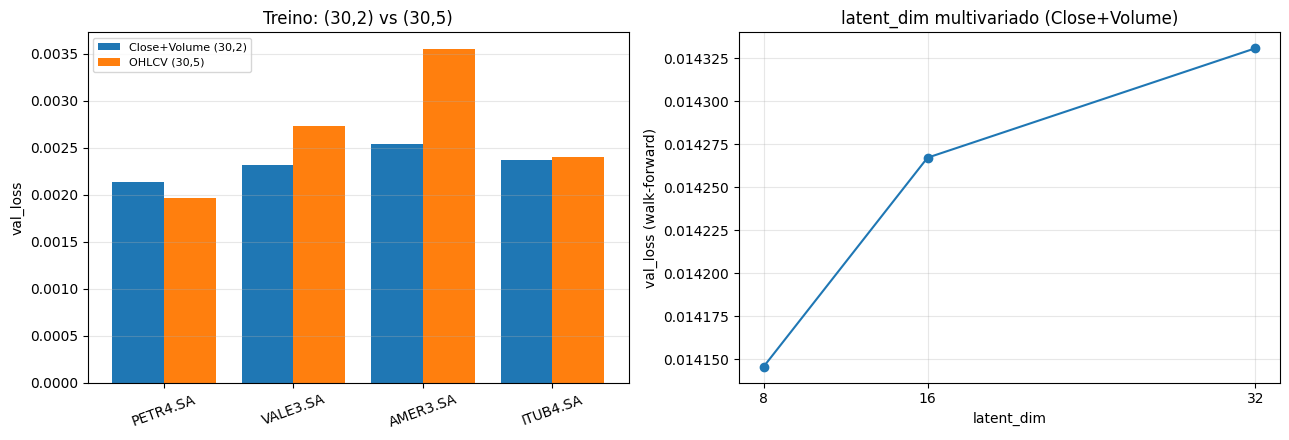

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(cmp))
a1.bar(x-0.2, cmp['val_loss_cv2'], 0.4, label='Close+Volume (30,2)')
a1.bar(x+0.2, cmp['val_loss_ohlcv'], 0.4, label='OHLCV (30,5)')
a1.set_xticks(x); a1.set_xticklabels(cmp.index, rotation=20)
a1.set_ylabel('val_loss'); a1.set_title('Treino: (30,2) vs (30,5)'); a1.legend(fontsize=8); a1.grid(axis='y', alpha=0.3)
a2.plot(agg_ld.index, agg_ld.values, 'o-'); a2.set_xticks([8,16,32])
a2.set_xlabel('latent_dim'); a2.set_ylabel('val_loss (walk-forward)')
a2.set_title('latent_dim multivariado (Close+Volume)'); a2.grid(alpha=0.3)
fig.tight_layout(); save_fig(fig, 'm9_ohlcv_latent'); plt.show()

## Conclusões

- **Colinearidade (Seção 1):** O/H/L/C altamente correlacionados --- confirma a hipótese de
  redundância.
- **OHLCV vs Close+Volume (Seção 2):** comparar `val_loss`; se OHLCV não reduz o erro de forma
  relevante, a Etapa 2 **não compensa** o custo de 3 canais redundantes.
- **Atribuição preservada (Seção 3):** a detecção de volume sobrevive em ambas as configurações.
- **`latent_dim` multivariado (Seção 4):** confirma ou ajusta o gargalo para a entrada
  Close+Volume.
- **Decisão registrada no ADR-0011** na sequência deste notebook.